Project 2

Description: Project report 2 should naturally follow project report 1 on ”Data: Feature extraction, and
visualization” and cover what you have learned in the lectures and exercises of week 5 to 8 on
”Supervised learning: Classification and regression”. The report should therefore include two
02452 PROJECT 2 Fall 2025
sections. A section on regression and a section on classification. The report will be evaluated
based on how it addresses each of the questions asked below and an overall assessment of the
report quality


Importing Relevant Packages

In [1]:
# Import relevant packages
import numpy as np
import pandas as pd
from scipy.io import loadmat
import scipy.stats as st

import sklearn.linear_model as lm
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn import model_selection
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures


# Plotting style
sns.set_style('darkgrid')
sns.set_theme(font_scale=1.)

def setup_storage_for_experiment(K_outer, K_inner, num_hyperparams):
    # Setup storage for the optimal hyperparameters found from the inner CV
    optimal_hyperparameters = np.empty(K_outer)

    # Setup storage for model coefficients and errors for each experiment in all inner folds
    ws_inner = np.empty((M + 1, K_outer, K_inner, num_hyperparams))
    train_errors_inner = np.empty((K_outer, K_inner, num_hyperparams))
    test_errors_inner = np.empty((K_outer, K_inner, num_hyperparams))

    # Setup storage for model coefficients for each experiment in all outer folds
    ws_outer = {
        'not regularized': np.empty((M + 1, K_outer)),
        'regularized': np.empty((M + 1, K_outer))
    }
    # Setup storage for errors as a dictionary
    errors_outer = {
        'train': {
            'baseline (no features)': np.empty((K_outer, 1)), 
            'not regularized': np.empty((K_outer, 1)),
            'regularized': np.empty((K_outer, 1))
        },
        'test': {
            'baseline (no features)': np.empty((K_outer, 1)), 
            'not regularized': np.empty((K_outer, 1)),
            'regularized': np.empty((K_outer, 1))
        }
    }
    return optimal_hyperparameters, ws_inner, train_errors_inner, test_errors_inner, ws_outer, errors_outer

def plot_fold_errors(fold_errors):
    K = fold_errors.shape[0]

    # Scale figure width with number of folds
    base_width = 6   # minimum width
    width_per_fold = 0.25  # additional width per fold
    max_width = 20   # cap to prevent it from getting absurdly wide
    fig_width = min(base_width + K * width_per_fold, max_width)
    fig_height = 6
    f = plt.figure(figsize=(fig_width, fig_height))

    bar_width = 0.35
    index = np.arange(K)
    plt.bar(index, fold_errors[:, 0], bar_width, color='tab:blue', label='Train error')
    plt.bar(index + bar_width, fold_errors[:, 1], bar_width, color='tab:red', label='Test error')
    plt.xlabel('Fold')
    plt.ylabel('RMSE')
    plt.ylim(0, max(fold_errors.flatten()) + 0.2)
    plt.xlim(-0.5, K - 0.5 + bar_width)
    plt.legend()
    plt.grid(axis='x')

    if K > 20:
        step = max(1, K // 20)  # show ~20 labels max
        plt.xticks(index[::step] + bar_width / 2, [f'{i+1}' for i in range(0, K, step)])

    else:
        plt.xticks(index + bar_width / 2, [f'{i+1}' for i in range(K)])

def print_regularization_results(errors):
    # Display results
    print("Linear regression without regularization:")
    print(f"- Training error: \t{errors['train']['not regularized'].mean():.4f}")
    print(f"- Test error: \t\t{errors['test']['not regularized'].mean():.4f}")
    print(f"- R^2 train: \t\t{(errors['train']['baseline (no features)'].sum() - errors['train']['not regularized'].sum()) / errors['train']['baseline (no features)'].sum():.4f}")
    print(f"- R^2 test: \t\t{(errors['test']['baseline (no features)'].sum() - errors['test']['not regularized'].sum()) / errors['test']['baseline (no features)'].sum():.4f}\n")

    print("Regularized linear regression:")
    print(f"- Training error: \t{errors['train']['regularized'].mean():.4f}")
    print(f"- Test error: \t\t{errors['test']['regularized'].mean():.4f}")
    print(f"- R^2 train: \t\t{(errors['train']['baseline (no features)'].sum() - errors['train']['regularized'].sum()) / errors['train']['baseline (no features)'].sum():.4f}")
    print(f"- R^2 test: \t\t{(errors['test']['baseline (no features)'].sum() - errors['test']['regularized'].sum()) / errors['test']['baseline (no features)'].sum():.4f}\n")

def get_model(input_dim, hidden_dim, output_dim):
    ### BEGIN SOLUTION
    return torch.nn.Sequential(
        torch.nn.Linear(in_features=input_dim, out_features=hidden_dim, bias=True),     # Input layer
        torch.nn.Tanh(),                                                                # Activation function
        torch.nn.Linear(in_features=hidden_dim, out_features=output_dim, bias=True),    # Output layer
    )
    ### END SOLUTION

Regression, part a:

1. Explain what variable is predicted based on which other variables and what you hope to
accomplish by the regression. Mention your feature transformation choices such as one-ofK coding. Since we will use regularization momentarily, apply a feature transformation to
your data matrix X such that each column has mean 0 and standard deviation 1^1



In [2]:
# Loading the data
columns = [
    'Sequence Name', 'mcg', 'gvh', 'lip', 'chg', 'aac', 'alm1', 'alm2', 'class'
]

df = pd.read_fwf("data/ecoli.data", header=None, names=columns)

# Define predictors (X) and target (y)
X = df.drop(columns=['mcg', 'class', 'Sequence Name'])
y = df['mcg']

#Scaling X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = X_scaled
N, M = X_scaled.shape
print(X_scaled)
print(columns)

[[-1.41953086 -0.17514236 -0.05463584  0.49078096 -1.20771743 -0.7160837 ]
 [-0.67596708 -0.17514236 -0.05463584  0.32710612 -0.69711074 -0.28566488]
 [-0.67596708 -0.17514236 -0.05463584 -0.08208098 -0.60427317 -0.19001625]
 ...
 [ 0.67596708 -0.17514236 -0.05463584 -0.49126808 -0.51143559 -0.57261076]
 [ 0.74356378 -0.17514236 -0.05463584 -0.65494292 -0.37217922 -0.62043507]
 [ 1.62232098 -0.17514236 -0.05463584 -1.55515454  0.13842746  0.09692964]]
['Sequence Name', 'mcg', 'gvh', 'lip', 'chg', 'aac', 'alm1', 'alm2', 'class']


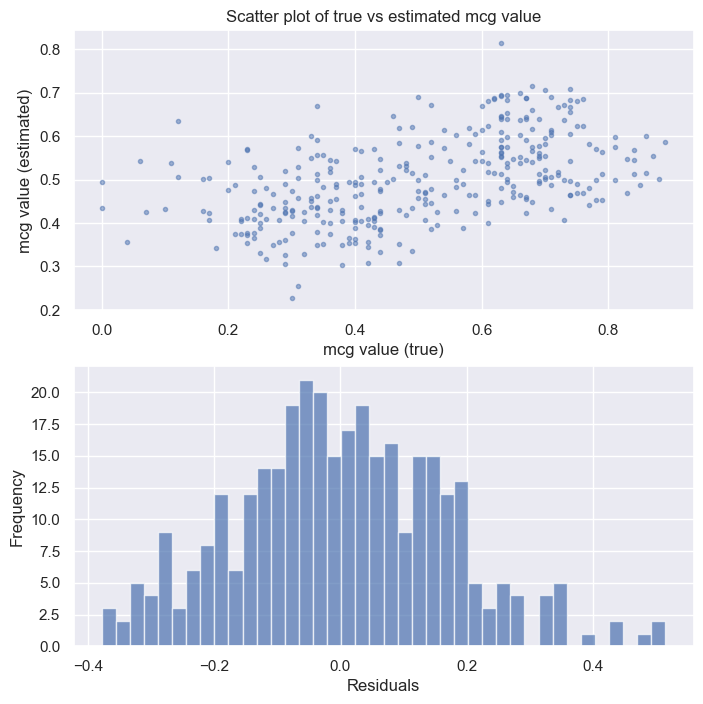

Estimated parameters:
gvh: 0.079
alm2: 0.633

MSE: 0.028


In [3]:
X = df[['gvh','alm2']]
y = df['mcg']

# Fit the linear regression model
model = lm.LinearRegression(fit_intercept=True)
model.fit(X, y)
# Estimated parameters (intercept and coefficients)
w_star = np.hstack([model.intercept_, model.coef_.flatten()])  # Estimated parameters

# Predict alcohol content
y_est = model.predict(X)
# Calculate residuals
residual = y_est - y

### END SOLUTION

# Display scatter plot and histogram of residuals
fig, axs = plt.subplots(2, 1, figsize=(8, 8))
axs[0].scatter(y, y_est, marker='.', alpha=0.5)
axs[0].set_xlabel("mcg value (true)")
axs[0].set_ylabel("mcg value (estimated)")
axs[0].set_title("Scatter plot of true vs estimated mcg value")
axs[1].hist(residual, bins=40, alpha=0.7)
axs[1].set_xlabel("Residuals")
axs[1].set_ylabel("Frequency")
plt.show()

# Estimated parameters, and their attribute names
print("\033[1mEstimated parameters:\033[0;0m")      # Bold text for emphasis
for i, name in enumerate(X.columns):
    print(f"{name}: {w_star[i].item():.3f}")

print(f"\nMSE: {np.mean(residual**2):.3f}")

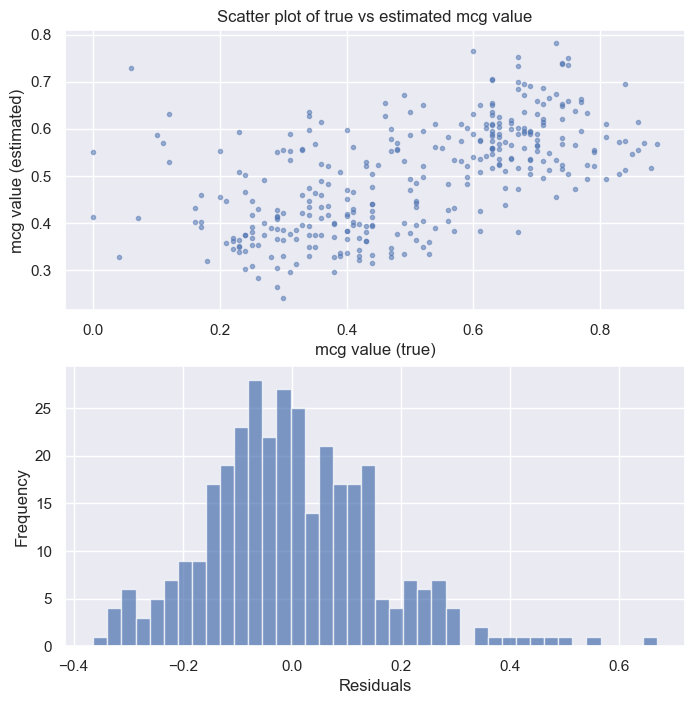

Estimated parameters:
gvh: -0.166
lip: 0.458
chg: 0.129
aac: 0.324
alm1: 0.183
alm2: 0.389

MSE: 0.025


In [4]:
X = df.drop(columns=['mcg', 'class', 'Sequence Name'])
y = df['mcg']

# Fit the linear regression model
model = lm.LinearRegression(fit_intercept=True)
model.fit(X, y)
# Estimated parameters (intercept and coefficients)
w_star = np.hstack([model.intercept_, model.coef_.flatten()])  # Estimated parameters

# Predict alcohol content
y_est = model.predict(X)
# Calculate residuals
residual = y_est - y

### END SOLUTION

# Display scatter plot and histogram of residuals
fig, axs = plt.subplots(2, 1, figsize=(8, 8))
axs[0].scatter(y, y_est, marker='.', alpha=0.5)
axs[0].set_xlabel("mcg value (true)")
axs[0].set_ylabel("mcg value (estimated)")
axs[0].set_title("Scatter plot of true vs estimated mcg value")
axs[1].hist(residual, bins=40, alpha=0.7)
axs[1].set_xlabel("Residuals")
axs[1].set_ylabel("Frequency")
plt.show()

# Estimated parameters, and their attribute names
print("\033[1mEstimated parameters:\033[0;0m")      # Bold text for emphasis
for i, name in enumerate(X.columns):
    print(f"{name}: {w_star[i].item():.3f}")

print(f"\nMSE: {np.mean(residual**2):.3f}")

2. Introduce a regularization parameter λ as discussed in 14 of the lecture notes, and estimate
the generalization error for different values of λ. Specifically, choose a reasonable range of
values of λ (ideally one where the generalization error first drop and then increases), and
for each value use K = 10 fold cross-validation (algorithm 5) to estimate the generalization
error. Include a figure of the estimated generalization error as a function of λ in the report
and briefly discuss the result

Intercept: 0.5000595238095238


,Feature,Weight
0,gvh,0.067192
4,alm1,0.063401
3,aac,0.021350
1,lip,0.013420
2,chg,0.008185
5,alm2,-0.013671


Optimal λ = 31.623, Test MSE = 0.0261


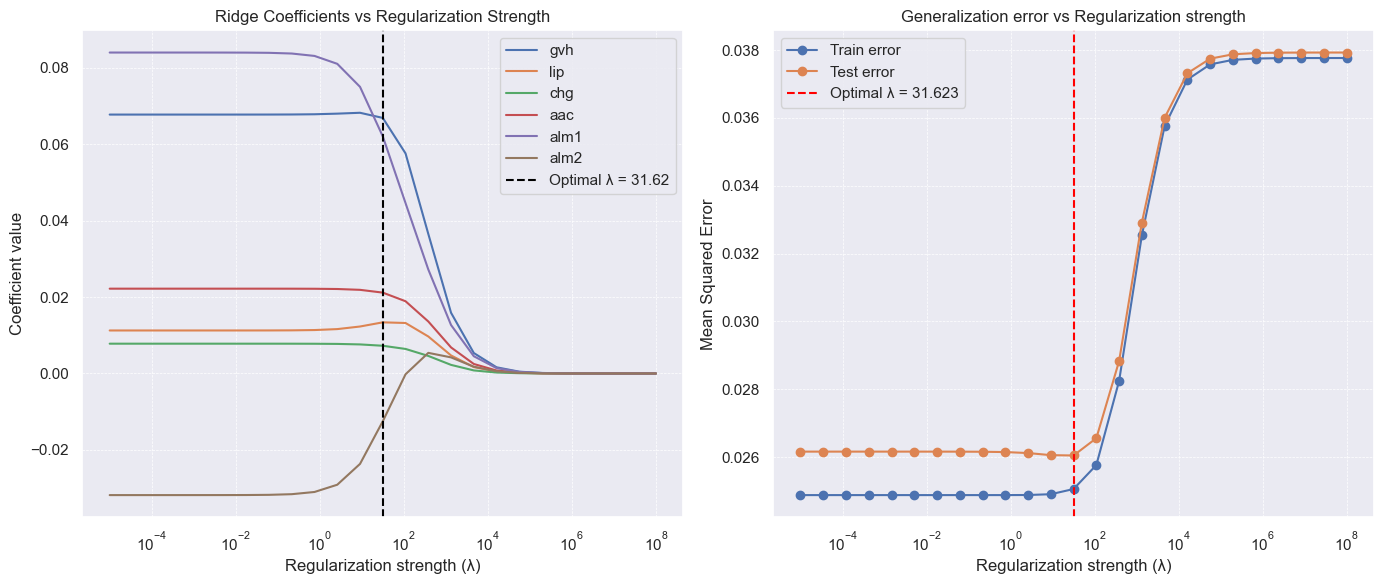

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

# Define range of regularization parameters (λ)
lambdas = np.logspace(-5, 8, 25)
np.random.seed(1234)

# Set up 10-fold cross-validation
K = 10
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Prepare storage
train_errors = []
test_errors = []
coefficients = []  # store average coefficients across folds for each lambda

# Loop over λ values
for lam in lambdas:
    ridge = Ridge(alpha=lam)
    fold_train_errors = []
    fold_test_errors = []
    fold_coefs = []  # store coefficients for each fold

    for train_index, test_index in kf.split(X_scaled):
        X_train, X_test = X_scaled[train_index], X_scaled[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        ridge.fit(X_train, y_train)
        y_train_pred = ridge.predict(X_train)
        y_test_pred = ridge.predict(X_test)

        fold_train_errors.append(mean_squared_error(y_train, y_train_pred))
        fold_test_errors.append(mean_squared_error(y_test, y_test_pred))
        fold_coefs.append(ridge.coef_)  # save model weights for this fold

    # Store mean errors and mean coefficients across folds
    train_errors.append(np.mean(fold_train_errors))
    test_errors.append(np.mean(fold_test_errors))
    coefficients.append(np.mean(fold_coefs, axis=0))

# Convert to numpy arrays
train_errors = np.array(train_errors)
test_errors = np.array(test_errors)
coefficients = np.array(coefficients)

# Find optimal λ (min test error)
opt_idx = np.argmin(test_errors)
opt_lambda = lambdas[opt_idx]

# Refit model on full dataset using optimal λ
final_model = Ridge(alpha=opt_lambda)
final_model.fit(X_scaled, y)

# Get feature names and coefficients
feature_names = df.drop(columns=['mcg', 'class', 'Sequence Name']).columns
weights = final_model.coef_
intercept = final_model.intercept_

# Create DataFrame
weights_df = pd.DataFrame({
    'Feature': feature_names,
    'Weight': weights
}).sort_values(by='Weight', ascending=False)

print("Intercept:", intercept)
display(weights_df)

print(f"Optimal λ = {opt_lambda:.3f}, Test MSE = {test_errors[opt_idx]:.4f}")

# --- Create side-by-side plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))


# Left: Coefficient Shrinkage
for i, feature in enumerate(df.drop(columns=['mcg', 'class', 'Sequence Name']).columns):
    axes[0].semilogx(lambdas, coefficients[:, i], label=feature)

axes[0].axvline(opt_lambda, color='black', linestyle='--', label=f"Optimal λ = {opt_lambda:.2f}")
axes[0].set_xlabel("Regularization strength (λ)")
axes[0].set_ylabel("Coefficient value")
axes[0].set_title("Ridge Coefficients vs Regularization Strength")
axes[0].legend(loc='best')
axes[0].grid(True, which="both", linestyle='--', linewidth=0.5)

# Right: MSE vs Regularization Strength
axes[1].semilogx(lambdas, train_errors, label="Train error", marker='o')
axes[1].semilogx(lambdas, test_errors, label="Test error", marker='o')
axes[1].axvline(opt_lambda, color='red', linestyle='--', label=f"Optimal λ = {opt_lambda:.3f}")
axes[1].set_xlabel("Regularization strength (λ)")
axes[1].set_ylabel("Mean Squared Error")
axes[1].set_title("Generalization error vs Regularization strength")
axes[1].legend()
axes[1].grid(True, which="both", linestyle='--', linewidth=0.5)


plt.tight_layout()
plt.show()


3. Explain how the output, y, of the linear model with the lowest generalization error (as
determined in the previous question) is computed for a given input x. What is the effect
of an individual attribute in x on the output, y, of the linear model? Does the effect of
individual attributes make sense based on your understanding of the problem?

Regression, part b: In this section, we will compare three models: the regularized linear regression model from the previous section, an artificial neural network (ANN) and a baseline. We
are interested in two questions: Is one model better than the other? Is either model better than
a trivial baseline?. We will attempt to answer these questions with two-level cross-validation.


1. Implement two-level cross-validation (see algorithm 6 of the lecture notes). We will use
2-level cross-validation to compare the models with K1 = K2 = 10 folds2
. As a baseline
model, we will apply a linear regression model with no features, i.e. it computes the mean
of y on the training data, and use this value to predict y on the test data.
Make sure you can fit an ANN model to the data. As complexity-controlling parameter
for the ANN, we will use the number of hidden units3 h. Based on a few test-runs, select
a reasonable range of values for h (which should include h = 1), and describe the range of
values you will use for h and λ.

In [ ]:
X = np.array(X)
y = np.array(y)

np.random.seed(1234)
K_outer = 10
K_inner = 10

CV_outer = KFold(K_outer, shuffle=True, random_state=1234)
CV_inner = KFold(K_inner, shuffle=True, random_state=1234)

# --- Hyperparameters to test ---
lambdas = np.logspace(-5, 8, 25)        # for Ridge
hidden_units = [1, 3, 5]     # for ANN
alphas = [1e-4, 1e-2, 1]          # ANN regularization strength

# --- Store results ---
results = []

# --- Outer cross-validation loop ---
for outer_fold, (outer_train_idx, outer_test_idx) in enumerate(CV_outer.split(X, y)):
    X_train_outer, X_test_outer = X[outer_train_idx], X[outer_test_idx]
    y_train_outer, y_test_outer = y[outer_train_idx], y[outer_test_idx]

    # ---------- INNER LOOP FOR ANN ----------
    inner_errors = np.zeros((len(hidden_units), len(alphas)))

    for i, h in enumerate(hidden_units):
        for j, alpha in enumerate(alphas):
            fold_errors = []
            for inner_train_idx, inner_val_idx in CV_inner.split(X_train_outer):
                X_train_inner, X_val_inner = X_train_outer[inner_train_idx], X_train_outer[inner_val_idx]
                y_train_inner, y_val_inner = y_train_outer[inner_train_idx], y_train_outer[inner_val_idx]

                # Train ANN
                ann = MLPRegressor(hidden_layer_sizes=(h,), alpha=alpha, max_iter=2500, early_stopping=True, random_state=1234)
                ann.fit(X_train_inner, y_train_inner)
                y_val_pred = ann.predict(X_val_inner)
                fold_errors.append(mean_squared_error(y_val_inner, y_val_pred))

            inner_errors[i, j] = np.mean(fold_errors)

    # Find optimal (h, alpha)
    i_opt, j_opt = np.unravel_index(np.argmin(inner_errors), inner_errors.shape)
    h_opt = hidden_units[i_opt]
    alpha_opt = alphas[j_opt]

    # Train ANN on full outer training set using best hyperparameters
    ann_final = MLPRegressor(hidden_layer_sizes=(h_opt,), alpha=alpha_opt, max_iter=2500, early_stopping=True, random_state=1234)
    ann_final.fit(X_train_outer, y_train_outer)
    y_pred_ann = ann_final.predict(X_test_outer)
    ann_test_mse = mean_squared_error(y_test_outer, y_pred_ann)

    # ---------- BASELINE ----------
    baseline_pred = np.ones_like(y_test_outer) * y_train_outer.mean()
    baseline_mse = mean_squared_error(y_test_outer, baseline_pred)

    # ---------- RIDGE ----------
    inner_ridge_errors = []
    for lam in lambdas:
        fold_errors = []
        for inner_train_idx, inner_val_idx in CV_inner.split(X_train_outer):
            X_train_inner, X_val_inner = X_train_outer[inner_train_idx], X_train_outer[inner_val_idx]
            y_train_inner, y_val_inner = y_train_outer[inner_train_idx], y_train_outer[inner_val_idx]
            ridge = Ridge(alpha=lam)
            ridge.fit(X_train_inner, y_train_inner)
            y_val_pred = ridge.predict(X_val_inner)
            fold_errors.append(mean_squared_error(y_val_inner, y_val_pred))
        inner_ridge_errors.append(np.mean(fold_errors))

    opt_lambda = lambdas[np.argmin(inner_ridge_errors)]
    ridge_final = Ridge(alpha=opt_lambda)
    ridge_final.fit(X_train_outer, y_train_outer)
    ridge_pred = ridge_final.predict(X_test_outer)
    ridge_test_mse = mean_squared_error(y_test_outer, ridge_pred)

    # ---------- Store all results ----------
    results.append({
        "Outer Fold": outer_fold + 1,
        "Ridge λ": opt_lambda,
        "Ridge Test MSE": ridge_test_mse,
        "ANN h*": h_opt,
        "ANN α*": alpha_opt,
        "ANN Test MSE": ann_test_mse,
        "Baseline Test MSE": baseline_mse
    })

# Convert results to DataFrame for easy viewing
results_df = pd.DataFrame(results)
display(results_df)


c:\Users\Change\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:697: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


In [8]:
selected_inner_fold = -1
selected_outer_fold = -1

# Get the weights for the selected outer and inner fold from ws_inner. Compare the bias term to the mean of the target variable in the training set.
### BEGIN SOLUTION
print(f"Weights for outer fold {selected_outer_fold} and inner fold {selected_inner_fold}:")
# Extract and print the weights for the selected fold
print(ws_inner[:, selected_outer_fold, selected_inner_fold, -1])

# Print the mean of the target variable in the training set for the last inner fold of the last outer fold
print(f"\nMean of target variable in training set: {np.mean(y_train_inner):.5f}")
# Compare the bias term (first entry) to the mean of the target variable
print(f"Bias term (intercept) from model: {ws_inner[0, selected_outer_fold, selected_inner_fold, -1]:.5f}")
### END SOLUTION

Weights for outer fold -1 and inner fold -1:
[4.99267399e-01 2.58458858e-07 7.62437227e-08 4.15037384e-08
 1.26042805e-07 2.17705107e-07 9.26790654e-08]

Mean of target variable in training set: 0.49278
Bias term (intercept) from model: 0.49927


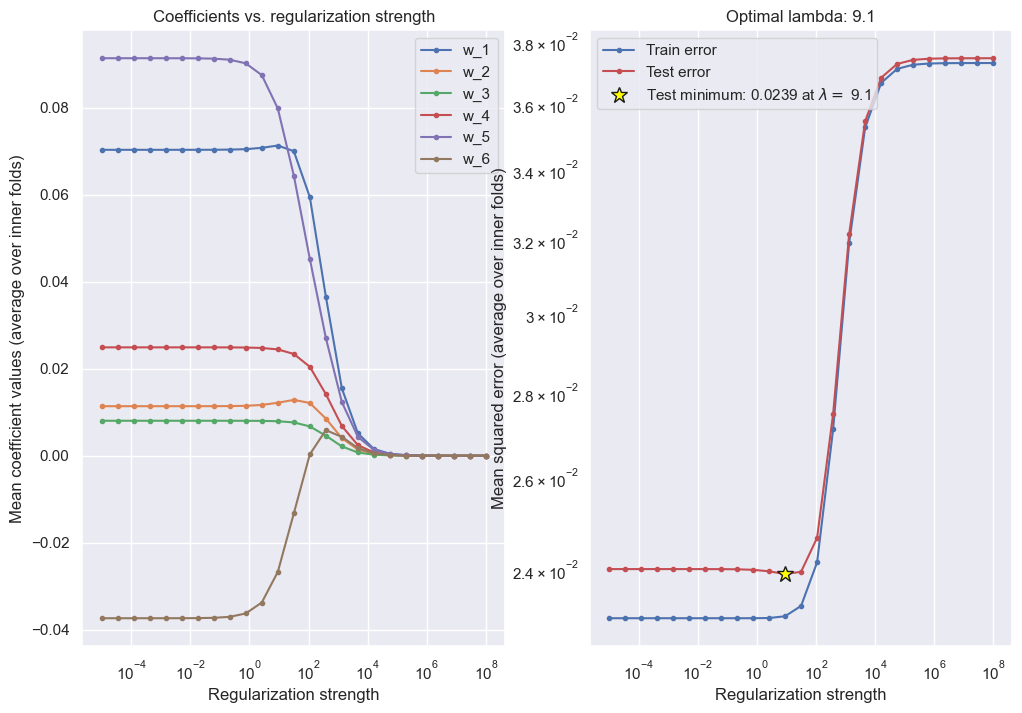

In [9]:
# Compute the mean training and validation error across inner folds for the selected outer fold
train_err_vs_lambda = np.mean(train_errors_inner[selected_outer_fold], axis=0)
test_err_vs_lambda = np.mean(test_errors_inner[selected_outer_fold], axis=0)

# Compute the mean coefficients across inner folds for the selected outer fold
mean_w_vs_lambda = np.squeeze(np.mean(ws_inner[:, selected_outer_fold, :, :], axis=1))


# Setup figure
plt.figure(figsize=(12, 8))

# Plot the mean coefficients across inner folds vs regularization strength for the selected outer fold
plt.subplot(1, 2, 1)
plt.title("Coefficients vs. regularization strength")
plt.semilogx(lambdas, mean_w_vs_lambda.T[:, 1:], ".-")  # Don't plot the bias term
plt.xlabel("Regularization strength")
plt.ylabel("Mean coefficient values (average over inner folds)")
plt.legend([f"w_{i}" for i in range(1, mean_w_vs_lambda.shape[0])])

# Plot the mean training and validation error vs regularization strength for the selected outer fold
plt.subplot(1, 2, 2)
plt.title(f"Optimal lambda: {optimal_regularization_strengths[selected_outer_fold]:.2g}")
plt.loglog(lambdas, train_err_vs_lambda.T, "b.-", lambdas, test_err_vs_lambda.T, "r.-")
plt.semilogx(optimal_regularization_strengths[selected_outer_fold], test_err_vs_lambda.min(), "*", color='yellow', markersize=12, markeredgecolor='k')
plt.xlabel("Regularization strength")
plt.ylabel("Mean squared error (average over inner folds)")
plt.legend(["Train error", "Test error", r"Test minimum: {:.4f} at $\lambda=$ {:.2g}".format(test_err_vs_lambda.min(), optimal_regularization_strengths[selected_outer_fold])])
plt.show()

In [10]:
# Assuming your 6 features are the first 6 columns of df (index 0 to 5)
feature_names = df.columns[2:8].tolist()
# The weights list must include the 'Intercept' first, then the features
coefficient_index = ['Intercept'] + feature_names

# Corrected code for DataFrame creation:
unregularized = pd.DataFrame(ws_outer['not regularized'],
    index=coefficient_index,  # Length 7
    columns=[f'Outer fold {i+1}' for i in range(K_outer)]
).T

regularized = pd.DataFrame(
    ws_outer['regularized'],
    index=coefficient_index,  # Length 7
    columns=[f'Outer fold {i+1}' for i in range(K_outer)]
).T

display(unregularized, regularized)

,Intercept,gvh,lip,chg,aac,alm1,alm2
Outer fold 1,0.498411,0.067069,0.008939,9.914300e-03,0.021814,0.083133,-0.036061
Outer fold 2,0.495364,0.070343,0.013974,9.583736e-03,0.023261,0.079538,-0.021633
Outer fold 3,0.505596,0.070096,0.015069,8.179847e-03,0.022072,0.081222,-0.028640
Outer fold 4,0.496722,0.071854,0.011815,9.416744e-03,0.025189,0.074100,-0.031142
Outer fold 5,0.495033,0.066005,0.008817,9.791369e-03,0.019446,0.090054,-0.033865
Outer fold 6,0.501225,0.065470,0.011624,9.729299e-03,0.023119,0.085405,-0.025843
Outer fold 7,0.502211,0.064591,0.008011,-1.647987e-17,0.020693,0.095219,-0.038937
Outer fold 8,0.505974,0.066394,0.012459,8.850825e-03,0.018114,0.079742,-0.030357
Outer fold 9,0.502112,0.066472,0.012813,9.208713e-03,0.024702,0.077785,-0.033193
Outer fold 10,0.497921,0.070318,0.011443,8.455061e-03,0.024890,0.091082,-0.037051


,Intercept,gvh,lip,chg,aac,alm1,alm2
Outer fold 1,0.498411,0.066424,0.011676,0.008920,0.020658,0.061699,-0.016928
Outer fold 2,0.495364,0.068090,0.015607,0.008871,0.022334,0.060638,-0.005645
Outer fold 3,0.505596,0.070435,0.015967,0.007981,0.022155,0.072730,-0.021051
Outer fold 4,0.496722,0.071895,0.012670,0.009165,0.024811,0.066453,-0.024125
Outer fold 5,0.495033,0.065758,0.011782,0.008846,0.018365,0.065446,-0.012055
Outer fold 6,0.501225,0.064296,0.013761,0.008890,0.021666,0.064942,-0.008283
Outer fold 7,0.502211,0.065615,0.009206,0.000000,0.020305,0.084196,-0.028775
Outer fold 8,0.505974,0.065550,0.014417,0.008179,0.017263,0.058946,-0.012052
Outer fold 9,0.502112,0.066708,0.013733,0.008953,0.024197,0.069695,-0.025719
Outer fold 10,0.497921,0.071236,0.012154,0.008362,0.024467,0.080619,-0.027412


2. Produce a table akin to Table 1 using two-level cross-validation (algorithm 6 in the lecture
notes). The table shows, for each of the K1 = 10 folds i, the optimal value of the number
of hidden units and regularization strength (h
∗
i
and λ
∗
i
respectively) as found after each
inner loop, as well as the estimated generalization errors E
test
i by evaluating on Dtest
i
. It
also includes the baseline test error, also evaluated on Dtest
i
. Importantly, you must re-use
the train/test splits D
par
i
, Dtest
i
for all three methods to allow statistical comparison (see
next section).


3. Statistically evaluate if there is a significant performance difference between the fitted
ANN, linear regression model and baseline using the methods described in ??. These
comparisons will be made pairwise (ANN vs. linear regression; ANN vs. baseline; linear
regression vs. baseline). We will allow some freedom in what test to choose. Therefore,
choose either:
setup I (11.3): Use the paired t-test described in 11.3.4
setup II (11.4): Use the method described in 11.4.1)
Include p-values and confidence intervals for the three pairwise tests in your report and
conclude on the results: Is one model better than the other? Are the two models better
than the baseline? Are some of the models identical? What recommendations would you
make based on what you’ve learned?


In [11]:
def correlated_ttest(r, rho, alpha=0.05):
    """
    Perform a correlated t-test to compare two models under Setup II.

    Parameters:
    - r (array-like): Array of performance differences across folds (e.g. r_j = error_A - error_B)
    - rho (float): Correlation coefficient between folds (typically 1/K for K-fold CV)
    - alpha (float, optional): Significance level (default: 0.05)

    Returns:
    - p (float): p-value of the test
    - CI (tuple): Confidence interval for the mean difference
    """

    r = np.array(r)
    r_hat = np.mean(r)
    s_hat = np.std(r, ddof=1)
    J = len(r)

    # Adjusted standard deviation accounting for correlation
    sigma_tilde = s_hat * np.sqrt((1 / J) + (rho / (1 - rho)))

    # Confidence interval
    CI = st.t.interval(1 - alpha, df=J - 1, loc=r_hat, scale=sigma_tilde)

    # Two-sided p-value
    p = 2 * st.t.cdf(-np.abs(r_hat) / sigma_tilde, df=J - 1)

    return r_hat, CI, p


In [21]:
ridge_errors = np.array([
    0.030257, 0.021718, 0.019305, 0.031407, 0.017971,
    0.023452, 0.026090, 0.029498, 0.019245, 0.042203
])

ann_errors = np.array([
    0.033794, 0.065976, 0.021084, 0.039021, 0.027214,
    0.028021, 1.624112, 0.053811, 0.019918, 0.064520
])

baseline_errors = np.array([
    0.046073, 0.027803, 0.030460, 0.044185, 0.029292,
    0.031965, 0.037501, 0.050590, 0.041005, 0.042071
])

rho = 1 / 10  # 10-fold correlation assumption

comparisons = {
    "ANN vs Ridge": ann_errors - ridge_errors,
    "ANN vs Baseline": ann_errors - baseline_errors,
    "Ridge vs Baseline": ridge_errors - baseline_errors
}

for name, diff in comparisons.items():
    diff = diff[~np.isnan(diff)]  # remove NaNs
    r_hat, CI, p = correlated_ttest(diff, rho)
    print(f"{name}:")
    print(f"  Mean difference = {r_hat:.4f}")
    print(f"  95% CI = [{CI[0]:.4f}, {CI[1]:.4f}]")
    print(f"  p-value = {p:.4f}\n")


ANN vs Ridge:
  Mean difference = 0.1716
  95% CI = [-0.3495, 0.6927]
  p-value = 0.4752

ANN vs Baseline:
  Mean difference = 0.1597
  95% CI = [-0.3618, 0.6811]
  p-value = 0.5060

Ridge vs Baseline:
  Mean difference = -0.0120
  95% CI = [-0.0188, -0.0051]
  p-value = 0.0033

